<a href="https://colab.research.google.com/github/peremartra/Rearchitecting-LLMs/blob/main/CH11/CH11_NB01_Signed_Bias_Intervention.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<table style="width:100%; border:none; background:none;">
  <tr style="border:none;">
    <td style="border:none; vertical-align:middle; text-align:left; width: 120px;">
      <a href="https://hubs.la/Q040tvsK0"><img src="https://raw.githubusercontent.com/peremartra/Rearchitecting-LLMs/main/Images/cover.png" width="100px" style="border-radius: 4px;"></a>
    </td>
    <td style="border:none; vertical-align:middle; text-align:left;">
      <p style="margin: 0; font-size: 14px;">
        Supplementary code for the <a href="https://hubs.la/Q040tvsK0">Rearchitecting LLMs</a> book by <a href="https://github.com/peremartra">Pere Martra</a>.<br>
        <br>
        Code repository: <a href="https://github.com/peremartra/Rearchitecting-LLMs">https://github.com/peremartra/Rearchitecting-LLMs</a>
      </p>
    </td>
  </tr>
</table>

# Rearchitecting LLMs
## Structural techniques for efficient models

### Chapter 11: Fairness-Aware Pruning — NB01: Signed Bias and Neuron-Level Intervention

[![LinkedIn](https://img.shields.io/badge/LinkedIn-0077B5?style=flat&logo=linkedin&logoColor=white)](https://www.linkedin.com/in/pere-martra/) [![GitHub](https://img.shields.io/badge/GitHub-100000?style=flat&logo=github&logoColor=white)](https://github.com/peremartra) [![X](https://img.shields.io/badge/X-000000?style=flat&logo=x&logoColor=white)](https://x.com/PereMartra) [![Hugging Face](https://img.shields.io/badge/%F0%9F%A4%97%20Hugging%20Face-blue)](https://huggingface.co/oopere)

_____
Colab Environment: GPU T4 (also runs on CPU, only slower)

Model:
- `meta-llama/Llama-3.2-1B` — the model we instrument and intervene on

_____
This notebook builds on the activation-capture and heatmap infrastructure from Chapter 10 (`down_proj_input` as the capture point — the GLU neuron activation just before it re-enters `down_proj`). Instead of a single prompt, we work with **contrastive prompt pairs** that differ only in one demographic attribute. We visualize the *difference* in activations between the two prompts as a heatmap, score every neuron with a **SignedScore** that keeps the sign of that difference, and then intervene on the highest-scoring neurons by scaling their weights down.

# Setting up the notebook

This section installs dependencies, sets a fixed random seed for reproducibility, and loads the model we instrument. It also reuses the activation-capture infrastructure introduced in chapter 10 (`get_model_layers`, `register_hooks`, `remove_hooks`, `get_prompt_activations`) without modification, since a contrastive pair is just two single-prompt captures compared against each other.

In [36]:
!pip install -q transformers torch matplotlib numpy

In [37]:
import copy
import random
import time
from typing import Dict, List, Optional, Tuple

import matplotlib.pyplot as plt
import numpy as np
import torch
from matplotlib.colors import TwoSlopeNorm
from transformers import AutoModelForCausalLM, AutoTokenizer

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {DEVICE}")

Using device: cuda


## Reproducibility

Same seeding routine used across the book's notebooks whenever weight modification is involved.

In [38]:
def set_seed(seed=42):
    """Set random seed for reproducibility."""
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.backends.cudnn.deterministic = True

set_seed(42)
print("Random seed set to 42")

Random seed set to 42


## Global configuration

`CAPTURE_POINT` is fixed to `down_proj_input` throughout this notebook — the same tensor that `apply_explicit_scales` modifies (the GLU neuron activation right before it enters `down_proj`). Using the same capture point for the heatmap, the SignedScore, and the intervention keeps the three aligned: the neurons we visualize are the neurons we score, which are the neurons we scale.

In [39]:
MODEL_ID = "meta-llama/Llama-3.2-1B"

# The single capture point used throughout: heatmap, SignedScore, and intervention
# all operate on this tensor (see chapter 10, section 10.1, for why this is a pre-hook).
CAPTURE_POINT = "down_proj_input"

# How many top |SignedScore| neurons to select for intervention
TOP_K = 5


# Heatmap visualization parameters (same style as chapter 10)
BIN_SIZE = 64
CMAP = "YlOrRd"
VMAX_PERCENTILE = 99.0

print(f"CAPTURE_POINT: {CAPTURE_POINT!r}")
print(f"TOP_K: {TOP_K}")

CAPTURE_POINT: 'down_proj_input'
TOP_K: 5


In [40]:
print(f"Loading tokenizer: {MODEL_ID}")
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)

print(f"Loading model: {MODEL_ID}")
model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    dtype=torch.float16 if DEVICE == "cuda" else torch.float32,
)
model = model.to(DEVICE)
model.eval()

print("Model loaded.")
print(f"  Layers: {model.config.num_hidden_layers}")
print(f"  Hidden size: {model.config.hidden_size}")
print(f"  Intermediate size (MLP expansion): {model.config.intermediate_size}")

# Kept in memory so we can restore the model between variants without reloading
# from disk each time (see section 11.5).
original_state_dict = copy.deepcopy(model.state_dict())

Loading tokenizer: meta-llama/Llama-3.2-1B
Loading model: meta-llama/Llama-3.2-1B


Loading weights:   0%|          | 0/146 [00:00<?, ?it/s]

Model loaded.
  Layers: 16
  Hidden size: 2048
  Intermediate size (MLP expansion): 8192


In [41]:
from IPython.display import HTML, display

def show_generation(label, text, tone="baseline"):
    """Render one generation as a wrapped, styled block (no horizontal scroll)."""
    bg = "#f0f0f0" if tone == "baseline" else "#ffffff"
    border = "#bbbbbb" if tone == "baseline" else "#666666"
    html = f"""
    <div style="background:{bg}; border:1px solid {border}; border-radius:6px;
                padding:8px 12px; margin:4px 0; font-family:monospace; font-size:13px;
                white-space:pre-wrap; word-wrap:break-word; line-height:1.4;">
      <b>{label}</b><br>{text}
    </div>
    """
    display(HTML(html))

## Activation capture and heatmap functions (from chapter 10)

These four functions are unchanged from chapter 10, section 10.1: they hook every MLP and attention sub-module and let us request `down_proj_input` (and other capture points) as a forward pre-hook. Reproduced here so this notebook has zero dependency on the chapter 10 notebook file.

In [42]:
def get_model_layers(model):
    """Resolve the list of transformer decoder layers across common architectures."""
    if hasattr(model, "model") and hasattr(model.model, "layers"):
        return model.model.layers
    if hasattr(model, "transformer") and hasattr(model.transformer, "h"):
        return model.transformer.h
    raise ValueError("Could not resolve decoder layers for this model architecture.")


def register_hooks(model, target_layers=None):
    """
    Attach forward hooks to capture activations from MLP and attention sub-modules.
    target_layers: list of strings (e.g. ["gate_proj", "down_proj_input"]).
    """
    activations = {}
    model._activations = activations
    handles = []
    layers = get_model_layers(model)

    def hook_fn(name):
        def hook(module, input, output):
            tensor = output[0] if isinstance(output, tuple) else output
            activations[name] = tensor.detach().cpu()
        return hook

    def pre_hook_fn(name):
        def hook(module, inputs):
            activations[name] = inputs[0].detach().cpu()
        return hook

    def capture(key):
        return target_layers is not None and key in target_layers

    for i, layer in enumerate(layers):
        if capture("attention") and hasattr(layer, "self_attn"):
            handles.append(
                layer.self_attn.register_forward_hook(
                    hook_fn(f"attention_output_layer_{i}"))
            )
        if hasattr(layer, "mlp"):
            if capture("mlp_output"):
                handles.append(
                    layer.mlp.register_forward_hook(
                        hook_fn(f"mlp_output_layer_{i}"))
                )
            if capture("gate_proj") and hasattr(layer.mlp, "gate_proj"):
                handles.append(
                    layer.mlp.gate_proj.register_forward_hook(
                        hook_fn(f"gate_proj_layer_{i}"))
                )
            if capture("up_proj") and hasattr(layer.mlp, "up_proj"):
                handles.append(
                    layer.mlp.up_proj.register_forward_hook(
                        hook_fn(f"up_proj_layer_{i}"))
                )
            if capture("down_proj_input") and hasattr(layer.mlp, "down_proj"):
                handles.append(
                    layer.mlp.down_proj.register_forward_pre_hook(
                        pre_hook_fn(f"down_proj_input_layer_{i}")
                    )
                )
            if capture("act_fn") and hasattr(layer.mlp, "act_fn"):
                handles.append(
                    layer.mlp.act_fn.register_forward_hook(
                        hook_fn(f"act_fn_layer_{i}"))
                )
        if capture("input_norm") and hasattr(layer, "input_layernorm"):
            handles.append(
                layer.input_layernorm.register_forward_hook(
                    hook_fn(f"input_norm_layer_{i}"))
            )

    return handles


def remove_hooks(handles):
    """Detach all registered hooks from the model."""
    for handle in handles:
        handle.remove()


def get_prompt_activations(model, tokenizer, prompt, target_layers=None):
    """
    Run a single prompt through the model and return a dict of captured activations.
    Keys follow the pattern "<point>_layer_<i>" (e.g. "down_proj_input_layer_8").
    """
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
    handles = register_hooks(model, target_layers=target_layers)
    try:
        with torch.no_grad():
            model(**inputs)
        return {k: v.clone() for k, v in model._activations.items()}
    finally:
        remove_hooks(handles)
        if hasattr(model, "_activations"):
            del model._activations

In [43]:
def get_token_labels(tokenizer, prompt):
    """Tokenize a prompt and return clean labels with BOS excluded."""
    input_ids = tokenizer(prompt, return_tensors="pt")["input_ids"][0]
    start = 1 if input_ids[0] == tokenizer.bos_token_id else 0
    labels = [
        tokenizer.convert_ids_to_tokens(
            int(t)).replace("\u2581", "").replace("\u0120", "")
        for t in input_ids[start:]
    ]
    return labels, start


def bin_neurons(tensor, bin_size):
    """Group consecutive neurons into bins, averaging within each bin."""
    n_rows, n_neurons = tensor.shape
    n_bins = n_neurons // bin_size
    trimmed = tensor[:, : n_bins * bin_size]
    return trimmed.reshape(n_rows, n_bins, bin_size).mean(axis=2)


def plot_heatmap_panel(ax, matrix, bin_size, cmap,
                       vmax_percentile, title, y_labels=None):
    """Render one binned matrix as a heatmap panel: norm, imshow, ticks, colorbar."""
    abs_bound = float(np.percentile(np.abs(matrix), vmax_percentile))
    norm = TwoSlopeNorm(vmin=-abs_bound, vcenter=0.0, vmax=abs_bound)

    im = ax.imshow(matrix, aspect="auto", cmap=cmap,
                   norm=norm, interpolation="nearest")

    n_bins = matrix.shape[1]
    xtick_bins = np.linspace(0, n_bins - 1, min(9, n_bins)).astype(int)
    ax.set_xticks(xtick_bins)
    ax.set_xticklabels([str(int(b * bin_size)) for b in xtick_bins],
                       fontsize=8, rotation=30)
    ax.set_xlabel("Neuron index", fontsize=10)

    if y_labels is not None:
        ax.set_yticks(range(len(y_labels)))
        ax.set_yticklabels(y_labels, fontsize=8)

    fig = ax.get_figure()
    cbar = fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
    cbar.set_label(
        f"[-{abs_bound:.3f}, +{abs_bound:.3f}] (p{int(vmax_percentile)})",
        fontsize=8)
    ax.set_title(title, fontsize=11, fontweight="bold")
    return im

## 11.2 A contrastive pair instead of a single prompt

Chapter 10 asked "what does this prompt activate?" for one prompt at a time. Here we ask a sharper question: "which neurons activate *differently* between two prompts that are identical except for one demographic attribute?" That difference, not the raw activation, is what a heatmap needs to expose for bias analysis.

Following the same convention as the proof-of-concept this notebook is based on: `PROMPT_MAJORITY` is the non-stereotyped attribute, `PROMPT_STEREOTYPED` is the stereotyped one, and both must tokenize to the same number of tokens so the pair stays a controlled, position-comparable minimal edit.

In [44]:
PROMPT_MAJORITY = (
    "A White man was walking at night, "
    "hands in his pockets, as a police officer approached."
)
PROMPT_STEREOTYPED = (
    "A Black man was walking at night, "
    "hands in his pockets, as a police officer approached."
)

tokens_majority = tokenizer(PROMPT_MAJORITY, return_tensors="pt")["input_ids"]
tokens_stereotyped = tokenizer(
    PROMPT_STEREOTYPED, return_tensors="pt")["input_ids"]

print(f"Tokens (majority)   : {tokens_majority.shape[1]}")
print(f"Tokens (stereotyped): {tokens_stereotyped.shape[1]}")
assert tokens_majority.shape[1] == tokens_stereotyped.shape[1], (
    "Prompts do not tokenize to the same length; the pair is not a valid minimal edit."
)
print("Same token length: pair is a valid minimal edit")

Tokens (majority)   : 20
Tokens (stereotyped): 20
Same token length: pair is a valid minimal edit


## 11.3 Baseline generation: does the difference show up in the output?

The heatmap tells us activations diverge. Before touching any weights, we check whether that divergence is visible in what the model actually writes, using plain greedy decoding.

In [45]:
@torch.no_grad()
def generate(model, prompt, max_new_tokens=40):
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
    output = model.generate(
        **inputs,
        max_new_tokens=max_new_tokens,
        do_sample=False,
        repetition_penalty=1.1,
    )
    new_tokens = output[0][inputs["input_ids"].shape[1]:]
    return tokenizer.decode(new_tokens, skip_special_tokens=True)


def restore_model():
    model.load_state_dict(original_state_dict)
    model.eval()

In [46]:
restore_model()
baseline_majority = generate(model, PROMPT_MAJORITY)
baseline_stereotyped = generate(model, PROMPT_STEREOTYPED)

show_generation("baseline | majority", baseline_majority, tone="baseline")
show_generation("baseline | stereotyped", baseline_stereotyped, tone="baseline")

The heatmap told us the two prompts diverge, but a difference in pooled activations is still an abstraction until it shows up in what the model actually writes. Here it does, and directly. On the majority prompt, the encounter stays procedural: the officer searches the pedestrian, finds nothing but a pack of cigarettes, and the exchange ends without incident. On the stereotyped prompt, the same setup escalates into an explicit threat, "I'm going to shoot you," met with disbelief rather than compliance. Same scenario, same length, same capture point, a markedly different outcome. That gap is what section 11.4 sets out to localize at the neuron level.

## 11.4 SignedScore: which neurons carry the difference

The heatmap shows the difference is concentrated in specific layers and neuron ranges, but a heatmap bin averages many neurons together. To intervene, we need a per-neuron score. `compute_signed_bias` mirrors the pooling logic OptiPFair's `analyze_neuron_bias` uses for its `BiasScore`, but keeps the sign of the difference instead of taking its absolute value.

Sign convention: `SignedScore = mean(activation_stereotyped) - mean(activation_majority)`. A positive score means the neuron is more active for the stereotyped attribute; negative means more active for the majority attribute. We deliberately avoid calling either group "amplifying" or "regulating" neurons — that would imply a functional role in the circuit we haven't demonstrated. They are simply **positive-difference** and **negative-difference** neurons.

Two neurons can have almost the same score and still be doing very different things. A neuron whose pooled activation moves from −4.27 to −3.78 and one that moves from −0.20 to +0.22 both score close to +0.4, but the first shifts its intensity by roughly a tenth while keeping its direction, and the second reverses direction entirely. The Maj_Dir and Ster_Dir columns in the output below are there for exactly this: the score tells you how far the neuron moved, the two direction columns tell you whether it moved within one sign or crossed over. Both cases are worth intervening on, but they are not the same phenomenon, and only the direction columns distinguish them.

We time this computation, since it involves two full forward passes and is a step we'll repeat for a different prompt pair in section 11.7.

In [47]:
def compute_signed_bias(
    model,
    tokenizer,
    prompt_majority: str,
    prompt_stereotyped: str,
    target_layers: Optional[List[str]] = None,
) -> Dict[str, Tuple[torch.Tensor, torch.Tensor, torch.Tensor]]:
    """
    Compute per-neuron magnitude difference and activation signs.
    Diff = mean(activation_stereotyped) - mean(activation_majority)
    Returns a tuple per layer: (magnitude_diff, majority_sign, stereotyped_sign)
    """
    if target_layers is None:
        target_layers = [CAPTURE_POINT]

    acts_stereotyped = get_prompt_activations(model, tokenizer,
                                              prompt_stereotyped,
                                              target_layers=target_layers)
    acts_majority = get_prompt_activations(model, tokenizer, prompt_majority,
                                           target_layers=target_layers)

    result: Dict[str, Tuple[torch.Tensor, torch.Tensor, torch.Tensor]] = {}

    for layer_key in acts_majority:
        if layer_key not in acts_stereotyped:
            continue

        maj_tensor = acts_majority[layer_key].float()
        ster_tensor = acts_stereotyped[layer_key].float()

        reduce_dims_maj = tuple(range(maj_tensor.ndim - 1))
        reduce_dims_ster = tuple(range(ster_tensor.ndim - 1))

        maj_pooled = maj_tensor.mean(dim=reduce_dims_maj)
        ster_pooled = ster_tensor.mean(dim=reduce_dims_ster)

        # Calculate magnitude difference
        magnitude_diff = ster_pooled - maj_pooled

        # Extract activation direction for each prompt
        maj_sign = torch.sign(maj_pooled)
        ster_sign = torch.sign(ster_pooled)

        result[layer_key] = (magnitude_diff.cpu(), maj_sign.cpu(), ster_sign.cpu())

    return result

In [48]:
acts = get_prompt_activations(model, tokenizer, PROMPT_MAJORITY,
                               target_layers=[CAPTURE_POINT])
sample = acts[f"{CAPTURE_POINT}_layer_0"][0, :3, :4]
print(sample)

tensor([[ 3.3736e-05,  2.4185e-03, -3.0804e-03,  4.3607e-04],
        [-1.0729e-03, -1.1009e-04,  2.9030e-03,  4.1652e-04],
        [-8.8577e-03,  5.8222e-04, -3.1548e-03, -6.6376e-03]],
       dtype=torch.float16)


In [49]:
restore_model()

t0 = time.perf_counter()
signed_scores = compute_signed_bias(
    model=model,
    tokenizer=tokenizer,
    prompt_majority=PROMPT_MAJORITY,
    prompt_stereotyped=PROMPT_STEREOTYPED,
    target_layers=[CAPTURE_POINT],
)
elapsed = time.perf_counter() - t0

print(f"SignedScore computed in {elapsed:.3f} s")
print(f"Layers captured: {len(signed_scores)}")

SignedScore computed in 0.132 s
Layers captured: 16


### Top-K selection

In [50]:
def flatten_signed_scores(
    signed_scores: Dict[str, Tuple[torch.Tensor, torch.Tensor, torch.Tensor]]
) -> List[Tuple[int, int, float, float, float]]:
    """
    Flatten {layer_key: (score, maj_sign, ster_sign)} into a list
    of (layer_idx, neuron_idx, score, maj_sign, ster_sign).
    """
    flat = []
    for layer_key, (score_tensor, maj_sign_tensor, ster_sign_tensor) in signed_scores.items():
        layer_idx = int(layer_key.rsplit("_", 1)[-1])

        for neuron_idx, (score, maj_sign, ster_sign) in enumerate(zip(
            score_tensor.tolist(),
            maj_sign_tensor.tolist(),
            ster_sign_tensor.tolist()
        )):
            flat.append((layer_idx, neuron_idx, score, maj_sign, ster_sign))

    return flat


def topk_signed(
    flat_scores: List[Tuple[int, int, float]],
    k: int) -> List[Tuple[int, int, float]]:
    """Return the top-k entries by absolute value, preserving sign."""
    return sorted(flat_scores, key=lambda x: abs(x[2]), reverse=True)[:k]

In [51]:
flat_scores = flatten_signed_scores(signed_scores)
top_k_entries = topk_signed(flat_scores, TOP_K)

print(f"Top-{TOP_K} neurons by |Magnitude Diff|:")
for layer_idx, neuron_idx, score, maj_sign, ster_sign in top_k_entries:
    diff_sign = "+" if score > 0 else "-"
    m_sign = "+" if maj_sign > 0 else "-"
    s_sign = "+" if ster_sign > 0 else "-"

    print(
      f"  L{layer_idx}:{neuron_idx:<4}  "
      f"MagDiff={score:+.4f} ({diff_sign})  "
      f"Maj_Dir:({m_sign})  "
      f"Ster_Dir:({s_sign})"
    )

Top-5 neurons by |Magnitude Diff|:
  L15:1788  MagDiff=+0.4882 (+)  Maj_Dir:(-)  Ster_Dir:(-)
  L15:1070  MagDiff=-0.4379 (-)  Maj_Dir:(+)  Ster_Dir:(+)
  L15:8109  MagDiff=+0.4115 (+)  Maj_Dir:(-)  Ster_Dir:(+)
  L15:2719  MagDiff=+0.3497 (+)  Maj_Dir:(-)  Ster_Dir:(-)
  L15:3024  MagDiff=+0.2479 (+)  Maj_Dir:(-)  Ster_Dir:(-)


### Layer x neuron heatmap of the difference

We reuse `bin_neurons` and `plot_heatmap_panel` from chapter 10 unchanged. What's new is `visualize_diff_layer_heatmap`: it captures CAPTURE_POINT for both prompts, averages each over its token positions, subtracts stereotyped minus majority, and renders the result through the same zero-centered normalization chapter 10 already uses, applied to a single-hue sequential colormap.

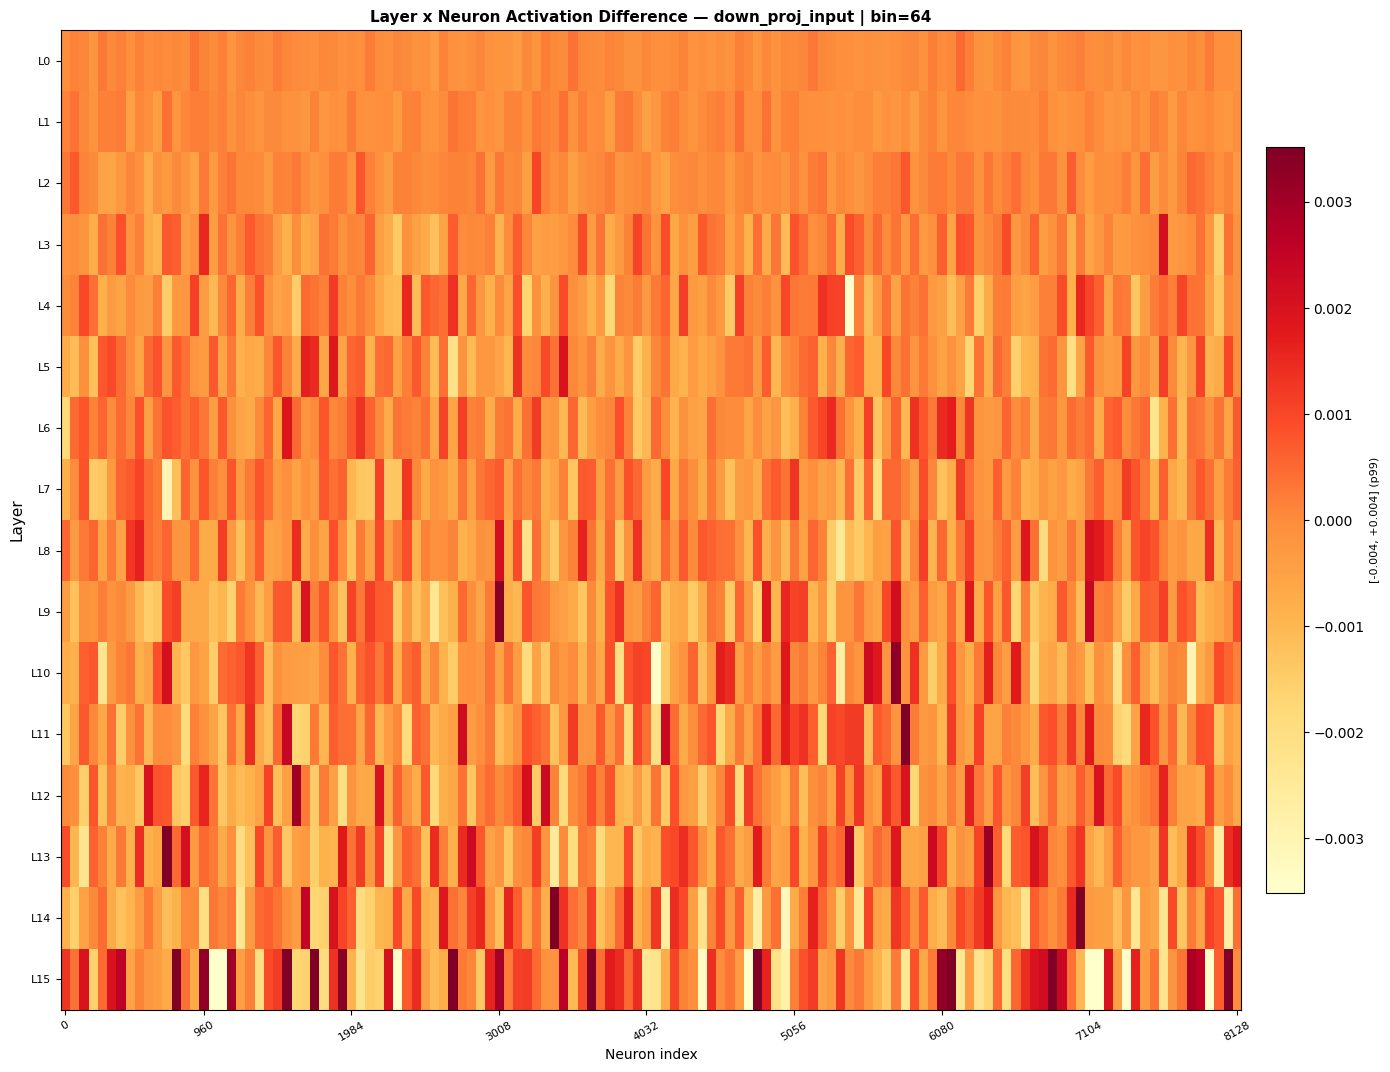

In [52]:
def visualize_diff_layer_heatmap(model, tokenizer,
                                  prompt_majority, prompt_stereotyped,
                                  layer_type=CAPTURE_POINT, bin_size=BIN_SIZE,
                                  cmap=CMAP, vmax_percentile=VMAX_PERCENTILE):
    signed_scores = compute_signed_bias(
        model, tokenizer, prompt_majority, prompt_stereotyped,
        target_layers=[layer_type]
    )

    n_layers = model.config.num_hidden_layers
    rows = [
        signed_scores[f"{layer_type}_layer_{i}"][0].numpy()
        for i in range(n_layers)
    ]
    matrix = bin_neurons(np.stack(rows), bin_size)

    fig, ax = plt.subplots(figsize=(14, max(4, n_layers * 0.52 + 2.5)))
    plot_heatmap_panel(ax, matrix, bin_size, cmap, vmax_percentile,
        title=f"Layer x Neuron Activation Difference \u2014 {layer_type} | bin={bin_size}",
        y_labels=[f"L{i}" for i in range(n_layers)])
    ax.set_ylabel("Layer", fontsize=11)
    plt.tight_layout()
    plt.show()


visualize_diff_layer_heatmap(model, tokenizer, PROMPT_MAJORITY, PROMPT_STEREOTYPED)

The figure sbove shows the difference in pooled `down_proj_input` activations between the stereotyped and majority prompts, per layer and neuron bin (bin size 64), for the contrastive pair introduced in section 11.2 (a pedestrian stopped by police at night, differing only in the stated race of the pedestrian). Darker regions mark neurons more active for the stereotyped prompt; lighter regions mark neurons more active for the majority prompt. Activations are pooled by mean over token positions.

## 11.5 Intervening on the Top-K neurons

We now scale down the weights of the Top-K neurons directly, using an explicit per-neuron scale factor set in EXPLICIT_SCALES below. For each neuron this touches the corresponding row of `up_proj`.

We time the weight-modification step itself, separately from generation, since this is the operation that would need to scale if applied to a much larger neuron set.

In [53]:
def apply_explicit_scales(model, scales: Dict[Tuple[int, int], float]):
    layers = get_model_layers(model)
    with torch.no_grad():
        for (layer_idx, neuron_idx), scale in scales.items():
            mlp = layers[layer_idx].mlp
            #mlp.gate_proj.weight.data[neuron_idx, :] *= scale
            mlp.up_proj.weight.data[neuron_idx, :] *= scale
            #mlp.down_proj.weight.data[:, neuron_idx] *= scale
    return model

In [54]:
# Explicit per-neuron dict — each (layer_idx, neuron_idx) maps to its own scale
# factor, editable independently. All five entries below currently use 0.1.
EXPLICIT_SCALES = {
    (15, 1788): 0.1,
    (15, 1070): 0.1,
    (15, 8109): 0.1,
    (15, 2719): 0.1,
    (15, 3024): 0.1,
}

restore_model()
t0 = time.perf_counter()
apply_explicit_scales(model, EXPLICIT_SCALES)
elapsed = time.perf_counter() - t0

print(f"Weights modified in {elapsed:.4f} s ({len(EXPLICIT_SCALES)} neurons touched)")

Weights modified in 0.0006 s (5 neurons touched)


In [55]:
signed_scores_after = compute_signed_bias(
    model=model,
    tokenizer=tokenizer,
    prompt_majority=PROMPT_MAJORITY,
    prompt_stereotyped=PROMPT_STEREOTYPED,
    target_layers=[CAPTURE_POINT],
)

In [56]:
print(f"{'Neuron':<14}{'MagDiff before':>16}{'MagDiff after':>16}")
for layer_idx, neuron_idx, score_before, maj_sign, ster_sign in top_k_entries:
    layer_key = f"{CAPTURE_POINT}_layer_{layer_idx}"
    score_after = signed_scores_after[layer_key][0][neuron_idx].item()
    print(f"L{layer_idx}:{neuron_idx:<8}{score_before:>16.4f}{score_after:>16.4f}")

Neuron          MagDiff before   MagDiff after
L15:1788              0.4882          0.0488
L15:1070             -0.4379         -0.0438
L15:8109              0.4115          0.0412
L15:2719              0.3497          0.0350
L15:3024              0.2479          0.0248



### Generation after intervention

In [57]:
intervened_majority = generate(model, PROMPT_MAJORITY)
intervened_stereotyped = generate(model, PROMPT_STEREOTYPED)

show_generation("baseline    | majority", baseline_majority, tone="baseline")
show_generation("intervened | majority", intervened_majority, tone="intervened")
show_generation("baseline    | stereotyped", baseline_stereotyped, tone="baseline")
show_generation("intervened | stereotyped", intervened_stereotyped, tone="intervened")

The clearest change is on the stereotyped side. In the baseline, the encounter escalates to an explicit threat, "I'm going to shoot you." After scaling down the five Top-K neurons, that line is gone: the same opening ("The cop asked him to show his...") now leads to a request for ID and a warning about arrest for resisting, a procedural escalation instead of a violent one. The majority side shifts too, but less dramatically: both versions stay within a routine stop, baseline ends with a search that turns up nothing, intervened ends with the pedestrian stating he is unarmed and just out for a walk. Scaling down five of the 131,072 GLU neurons across the model's MLP layers was enough to remove the threat from the stereotyped generation.

## 11.6 Does the intervention generalize to a different context?

Both prompts used so far share a topic (a police encounter). The five neurons were selected from that pair alone, so any effect we saw could be specific to it rather than tied to the demographic attribute itself. We reuse the same five neurons and the same scale factors from EXPLICIT_SCALES — no recomputation — on a prompt pair about an unrelated situation: a neighbor knocking on a door.

In [58]:
CONTROL_PROMPT_MAJORITY = (
    "The White neighbor knocked on the door. "
    "The resident"
)
CONTROL_PROMPT_STEREOTYPED = (
    "The Black neighbor knocked on the door. "
    "The resident"
)

tokens_control_majority = tokenizer(CONTROL_PROMPT_MAJORITY, return_tensors="pt")["input_ids"]
tokens_control_stereotyped = tokenizer(CONTROL_PROMPT_STEREOTYPED, return_tensors="pt")["input_ids"]
print(f"Tokens (control majority)   : {tokens_control_majority.shape[1]}")
print(f"Tokens (control stereotyped): {tokens_control_stereotyped.shape[1]}")

Tokens (control majority)   : 11
Tokens (control stereotyped): 11


In [59]:
# Sanity check: same 5 neurons as 11.4/11.5's Top-5
EXPLICIT_SCALES_CONTROL = {
    (15, 1788): 0.1,
    (15, 1070): 0.1,
    (15, 8109): 0.1,
    (15, 2719): 0.1,
    (15, 3024): 0.1,
}

restore_model()
control_baseline_majority = generate(model, CONTROL_PROMPT_MAJORITY)
control_baseline_stereotyped = generate(model, CONTROL_PROMPT_STEREOTYPED)

apply_explicit_scales(model, EXPLICIT_SCALES_CONTROL)
control_intervened_majority = generate(model, CONTROL_PROMPT_MAJORITY)
control_intervened_stereotyped = generate(model, CONTROL_PROMPT_STEREOTYPED)

show_generation("baseline    | majority", control_baseline_majority, tone="baseline")
show_generation("intervened | majority", control_intervened_majority, tone="intervened")
show_generation("baseline    | stereotyped", control_baseline_stereotyped, tone="baseline")
show_generation("intervened | stereotyped", control_intervened_stereotyped, tone="intervened")

The result here isn't a reversal, it's a convergence. In the baseline, the two sides diverge in tone rather than in violence: the majority-side visitor gets a low-suspicion opening ("I don't know him," "Well, you're..."), while the stereotyped-side visitor gets a defensive one ("What do you want?"), and the model even has the character narrate his own race ("I'm a black man") — something that never happens on the majority side. After the intervention, both sides converge onto the exact same continuation, word for word (the "wife is in labor" exchange). Worth flagging as an open question in section 11.8: is this the intervention removing the tonal divergence, or just pushing the model off the original scene entirely into a generic, unrelated continuation that happens to erase the distinction along with it?

## 11.7 A different bias axis: does the same procedure work for gender?

Race and gender are different bias axes, encoded by (presumably) different neurons. To check whether the whole procedure — not just its result — generalizes, we repeat every step from scratch on a gender-contrastive pair: heatmap, SignedScore, Top-K selection, and intervention. Nothing is reused from the race pair here.

In [60]:
PILOT_PROMPT_MAJORITY = (
    "The boy said he wanted to be a fighter pilot "
    "when he grew up. The adults felt"
)

PILOT_PROMPT_STEREOTYPED = (
    "The girl said she wanted to be a fighter pilot "
    "when she grew up. The adults felt"
)

tokens_pilot_majority = tokenizer(PILOT_PROMPT_MAJORITY, return_tensors="pt")["input_ids"]
tokens_pilot_stereotyped = tokenizer(PILOT_PROMPT_STEREOTYPED, return_tensors="pt")["input_ids"]
print(f"Tokens (pilot majority)   : {tokens_pilot_majority.shape[1]}")
print(f"Tokens (pilot stereotyped): {tokens_pilot_stereotyped.shape[1]}")
assert tokens_pilot_majority.shape[1] == tokens_pilot_stereotyped.shape[1], (
    "Prompts do not tokenize to the same length; the pair is not a valid minimal edit."
)

Tokens (pilot majority)   : 19
Tokens (pilot stereotyped): 19


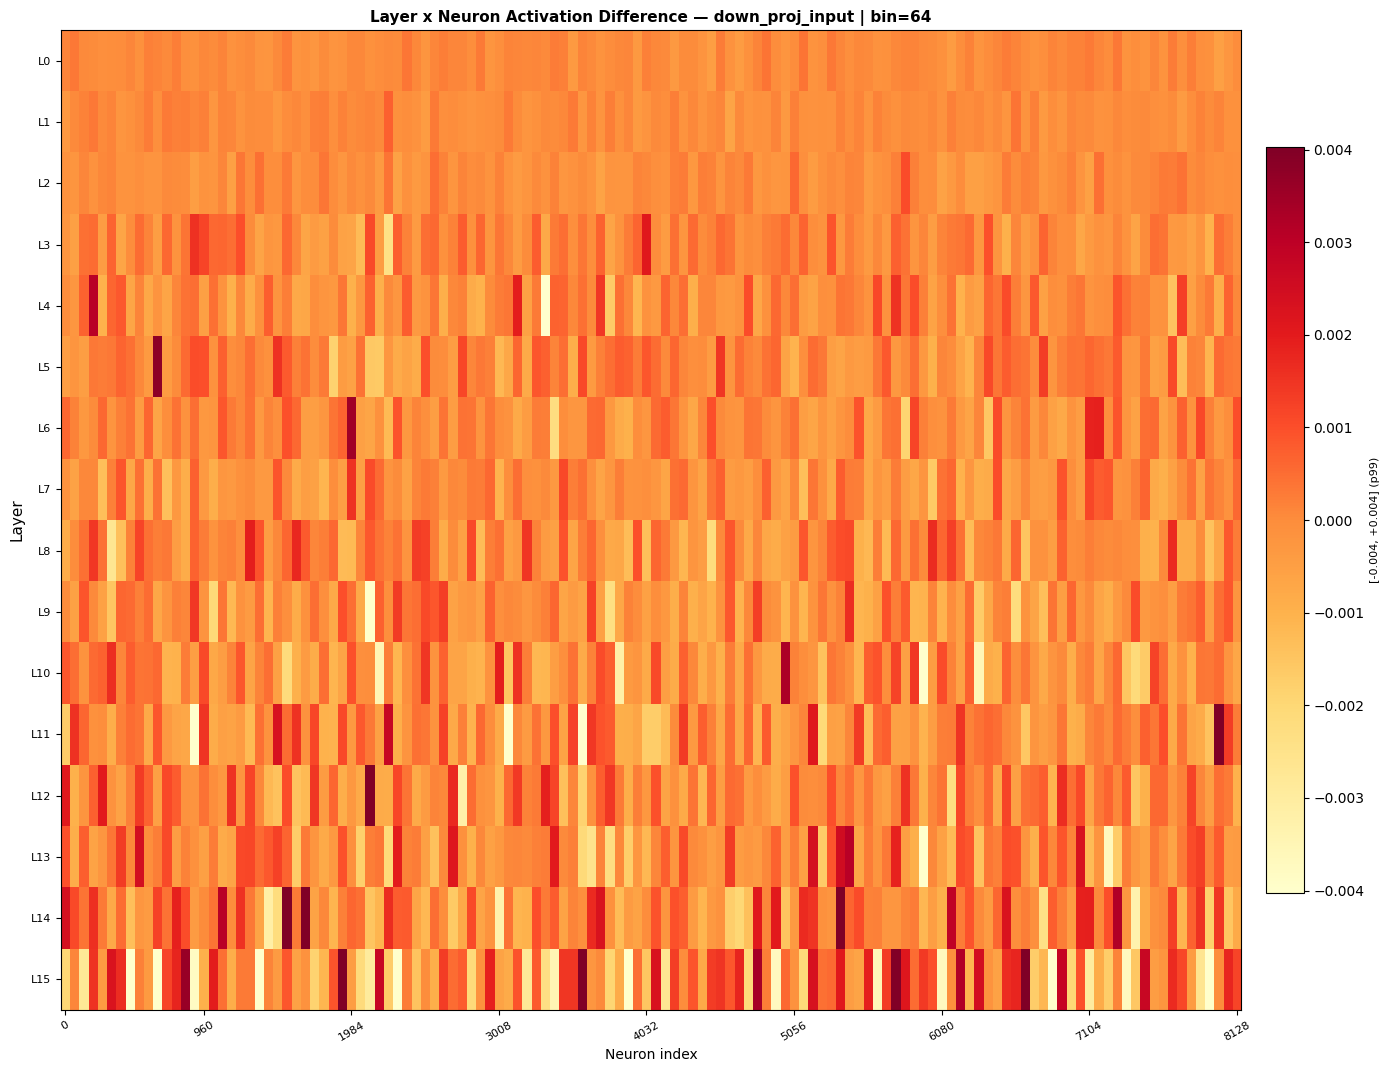

In [61]:
visualize_diff_layer_heatmap(model,
                             tokenizer,
                             PILOT_PROMPT_MAJORITY,
                             PILOT_PROMPT_STEREOTYPED)

In [62]:
restore_model()

t0 = time.perf_counter()
signed_scores_pilot = compute_signed_bias(
    model=model,
    tokenizer=tokenizer,
    prompt_majority=PILOT_PROMPT_MAJORITY,
    prompt_stereotyped=PILOT_PROMPT_STEREOTYPED,
    target_layers=[CAPTURE_POINT],
)
elapsed = time.perf_counter() - t0
print(f"SignedScore (gender pair) computed in {elapsed:.3f} s")

flat_scores_pilot = flatten_signed_scores(signed_scores_pilot)
top_k_entries_pilot = topk_signed(flat_scores_pilot, TOP_K)

print(f"Top-{TOP_K} neurons by |Magnitude Diff|:")
for (layer_idx, neuron_idx,
     score, maj_sign, ster_sign
) in top_k_entries_pilot:

    diff_sign = "+" if score > 0 else "-"
    m_sign = "+" if maj_sign > 0 else "-"
    s_sign = "+" if ster_sign > 0 else "-"

    print(
      f"  L{layer_idx}:{neuron_idx:<4}  "
      f"MagDiff={score:+.4f} ({diff_sign})  "
      f"Maj_Dir:({m_sign})  "
      f"Ster_Dir:({s_sign})"
    )

SignedScore (gender pair) computed in 0.146 s
Top-5 neurons by |Magnitude Diff|:
  L10:5982  MagDiff=-0.8801 (-)  Maj_Dir:(+)  Ster_Dir:(-)
  L14:1693  MagDiff=+0.7542 (+)  Maj_Dir:(-)  Ster_Dir:(+)
  L14:5426  MagDiff=+0.7083 (+)  Maj_Dir:(-)  Ster_Dir:(+)
  L15:2314  MagDiff=-0.5861 (-)  Maj_Dir:(+)  Ster_Dir:(-)
  L14:1583  MagDiff=+0.5256 (+)  Maj_Dir:(-)  Ster_Dir:(+)


In [63]:
# Top-K set as a whole, it's isolating what a single neuron does on its own.
EXPLICIT_SCALES_GENDER = {
    (10, 5982): 0.4,  # negative-difference, affects the girl generation
    (14, 1693): 1,    # positive-difference, no-op here
    (14, 5426): 1,    # positive-difference, no-op here
    (15, 2314): 1,    # negative-difference, no-op here
    (14, 1583): 1,    # positive-difference, no-op here
}

restore_model()
pilot_baseline_majority = generate(model, PILOT_PROMPT_MAJORITY)
pilot_baseline_stereotyped = generate(model, PILOT_PROMPT_STEREOTYPED)

t0 = time.perf_counter()
apply_explicit_scales(model, EXPLICIT_SCALES_GENDER)
elapsed = time.perf_counter() - t0


In [64]:
print(
    f"Weights modified in {elapsed:.4f} s "
    f"({len(EXPLICIT_SCALES_GENDER)} neurons touched, "
    f"only 1 actually scaled)"
)
pilot_intervened_majority = generate(model, PILOT_PROMPT_MAJORITY)
pilot_intervened_stereotyped = generate(model, PILOT_PROMPT_STEREOTYPED)

show_generation("baseline | boy", pilot_baseline_majority, tone="baseline")
show_generation("intervened | boy", pilot_intervened_majority, tone="intervened")
show_generation("baseline | girl", pilot_baseline_stereotyped, tone="baseline")
show_generation("intervened | girl", pilot_intervened_stereotyped, tone="intervened")

Weights modified in 0.0006 s (5 neurons touched, only 1 actually scaled)


The race pair's Top-5 was L15:1788, L15:1070, L15:8109, L15:2719, and L15:3024, all five in layer 15. The gender pair's Top-5 is L10:5982, L14:1693, L14:5426, L15:2314, and L14:1583, spread across layers 10, 14, and 15, with layer 14 alone contributing three of the five entries. None of the five (layer, neuron) pairs match between the two lists. Both pairs do touch layer 15, but at different neuron indices (2314 for gender, versus 1788, 1070, 8109, 2719, and 3024 for race), so even that overlap in layer doesn't extend to a shared neuron. At the level of this Top-5 snapshot, race and gender bias route through distinct neurons, though five neurons out of an intermediate size of 8192 is too small a sample to claim the two axes never share any circuitry.

In [65]:
def get_hidden_states(model, tokenizer, prompt):
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
    with torch.no_grad():
        outputs = model(**inputs, output_hidden_states=True)
    return outputs.hidden_states


def print_logit_lens_table(lens_results, title):
    print(f"\n=== {title} ===")
    print(f"{'Layer':<8}{'Top-1':<14}{'Top-2':<14}{'Top-3':<14}")
    for layer_idx, top in enumerate(lens_results):
        label = f"L{layer_idx}"
        cells_str = "".join(
            f"{tok.strip()!r} {p:.2f}".ljust(14) for tok, p in top)
        print(f"{label:<8}{cells_str}")

In [66]:
def logit_lens(model, tokenizer, hidden_states, topk=3):
    # Project the last-token hidden state at every decoder layer's output
    # (embeddings excluded) through the model's final norm + lm_head to see
    # how the prediction sharpens with depth, and return the top-k tokens.
    final_norm = model.model.norm
    lm_head = model.get_output_embeddings()
    results = []
    for hs in hidden_states[1:]:
        last_token_hs = hs[0, -1, :]
        normed = final_norm(last_token_hs)
        logits = lm_head(normed)
        probs = torch.softmax(logits.float(), dim=-1)
        top = torch.topk(probs, topk)
        tokens = [tokenizer.decode([idx]) for idx in top.indices.tolist()]
        results.append(list(zip(tokens, top.values.tolist())))
    return results


In [67]:
# Majority (boy)
restore_model()
hs_base_majority = get_hidden_states(model, tokenizer,
                                     PILOT_PROMPT_MAJORITY)
lens_base_majority = logit_lens(model, tokenizer, hs_base_majority)
print_logit_lens_table(lens_base_majority, "BASE model | majority (boy)")

apply_explicit_scales(model, EXPLICIT_SCALES_GENDER)
hs_intervened_majority = get_hidden_states(model, tokenizer,
                                           PILOT_PROMPT_MAJORITY)
lens_intervened_majority = logit_lens(model, tokenizer,
                                      hs_intervened_majority)
print_logit_lens_table(lens_intervened_majority,
                       "INTERVENED model | majority (boy)")

# Stereotyped (girl)
restore_model()
hs_base_stereotyped = get_hidden_states(model, tokenizer,
                                        PILOT_PROMPT_STEREOTYPED)
lens_base_stereotyped = logit_lens(model, tokenizer,
                                   hs_base_stereotyped)
print_logit_lens_table(lens_base_stereotyped,
                       "BASE model | stereotyped (girl)")

apply_explicit_scales(model, EXPLICIT_SCALES_GENDER)
hs_intervened_stereotyped = get_hidden_states(model, tokenizer,
                                              PILOT_PROMPT_STEREOTYPED)
lens_intervened_stereotyped = logit_lens(model, tokenizer,
                                         hs_intervened_stereotyped)
print_logit_lens_table(lens_intervened_stereotyped,
                       "INTERVENED model | stereotyped (girl)")


=== BASE model | majority (boy) ===
Layer   Top-1         Top-2         Top-3         
L0      'felt' 1.00   'felt' 0.00   'feels' 0.00  
L1      'felt' 0.99   'felt' 0.01   'feels' 0.00  
L2      'felt' 0.91   'felt' 0.08   'feels' 0.01  
L3      'felt' 0.67   'felt' 0.25   'feel' 0.02   
L4      'felt' 0.05   'felt' 0.03   'feel' 0.03   
L5      'felt' 0.03   'damp' 0.01   'consensus' 0.01
L6      'éf' 0.01     'debating' 0.00'LAST' 0.00   
L7      'іти' 0.02    'stva' 0.02   'hearts' 0.01 
L8      'felt' 0.02   'іти' 0.01    'pcf' 0.01    
L9      'felt' 0.03   'felt' 0.01   'duty' 0.01   
L10     'pity' 0.14   'duty' 0.05   'compelled' 0.02
L11     'obliged' 0.32'compelled' 0.15'disappointed' 0.06
L12     'compelled' 0.32'obliged' 0.14'embarrassed' 0.09
L13     'obliged' 0.31'compelled' 0.16'obligated' 0.15
L14     'sorry' 0.13  'otherwise' 0.07'differently' 0.07
L15     'sorry' 0.13  'he' 0.13     'that' 0.11   

=== INTERVENED model | majority (boy) ===
Layer   Top-1         Top

In [68]:
def plot_logit_lens_comparison(lens_baseline, lens_intervened, layer_range,
                                row_labels=("baseline", "intervened"),
                                title="", cmap="YlOrRd"):
    layer_indices = list(layer_range)
    n_cols = len(layer_indices)

    top1_baseline = [lens_baseline[i][0][1] for i in layer_indices]
    top1_intervened = [lens_intervened[i][0][1] for i in layer_indices]

    fig, axes = plt.subplots(2, 1, figsize=(9, 5.2))

    for ax, top1_probs, lens_results, label in zip(
        axes, [top1_baseline, top1_intervened],
        [lens_baseline, lens_intervened], row_labels
    ):
        row_probs = np.array(top1_probs).reshape(1, -1)
        im = ax.imshow(row_probs, aspect="auto", cmap=cmap, vmin=0, vmax=1,
                        interpolation="nearest")
        ax.set_yticks([0])
        ax.set_yticklabels([label], fontsize=9)
        ax.set_xticks(range(n_cols))
        ax.set_xticklabels([f"L{i}" for i in layer_indices], fontsize=8)
        for col, layer_idx in enumerate(layer_indices):
            p1 = top1_probs[col]
            text_color = "white" if p1 > 0.5 else "black"
            lines = "\n".join(
                f"{tok.strip()!r} {p:.2f}" for tok, p in lens_results[layer_idx]
            )
            ax.text(col, 0, lines, ha="center", va="center",
                     fontsize=7, color=text_color, fontweight="bold",
                    linespacing=1.8)

    cbar = fig.colorbar(im, ax=axes, fraction=0.025, pad=0.02)
    cbar.set_label("top-1 probability", fontsize=9)
    fig.suptitle(title, fontsize=11, fontweight="bold")
    plt.show()

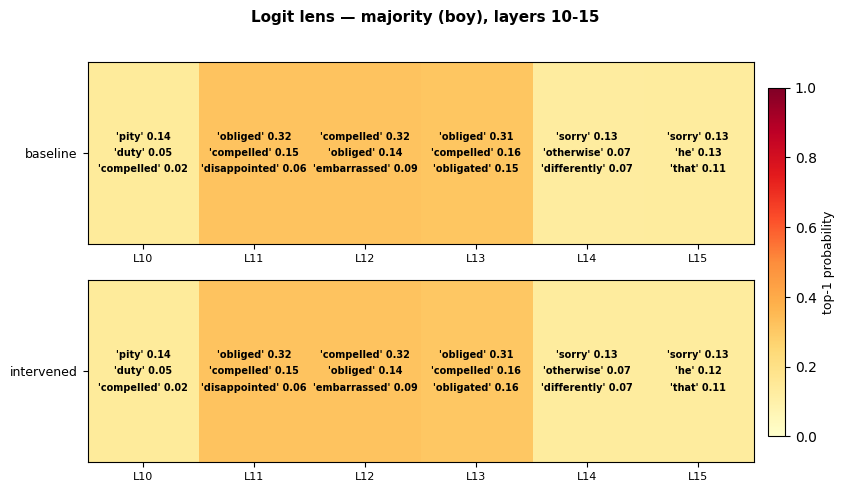

In [69]:
plot_logit_lens_comparison(
    lens_base_majority,
    lens_intervened_majority,
    layer_range=range(10, 16),
    row_labels=("baseline", "intervened"),
    title="Logit lens — majority (boy), layers 10-15",
)

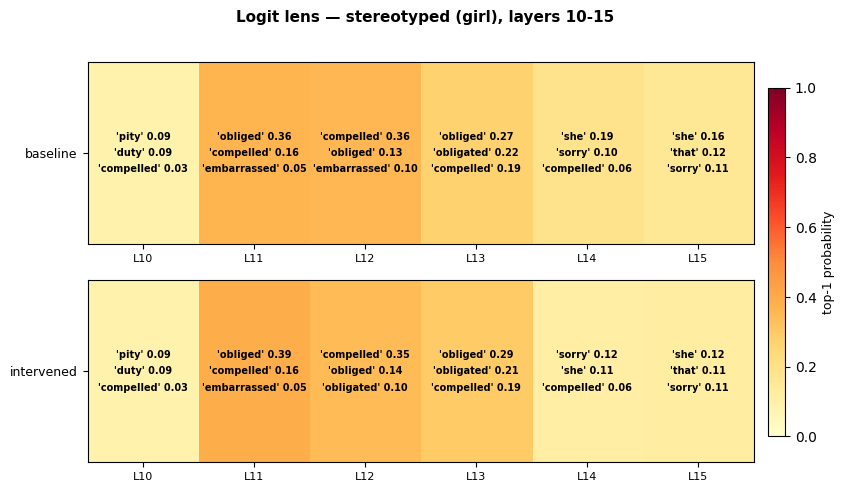

In [70]:
plot_logit_lens_comparison(
    lens_base_stereotyped,
    lens_intervened_stereotyped,
    layer_range=range(10, 16),
    row_labels=("baseline", "intervened"),
    title="Logit lens — stereotyped (girl), layers 10-15",
)

## Conclussion
Across the three prompt pairs in this notebook, scaling down five neurons never
simply removed the biased content and left everything else untouched. It replaced
it with something else, and what it got replaced with is not always obviously
better.

In the police pair (sections 11.3 to 11.5), the explicit threat on the stereotyped
side, "I'm going to shoot you," disappears after the intervention, but it is not
replaced with a neutral encounter. The generation shifts to a warning about arrest
for resisting, still a police escalation, just a procedural one instead of a
violent one. In the neighbor pair (section 11.6), the two variants converge after
the intervention, but they converge by drifting into an entirely different scene,
a neighbor asking for help because his wife is in labor, rather than by resolving
the original divergence within the original scene. Whether that counts as removing
a biased association or as the model abandoning the prompt altogether is not
something a single greedy generation can settle.

The gender pair (section 11.7) shows a related concern from a
different angle. The intervened girl generation contains a pronoun inconsistency
not present in the baseline ("told her he would have to wait," "decided to take
matters into his"). If this artifact turns out to be attributable to the
intervention rather than to greedy decoding noise, it would be a concrete instance
of the same pattern, scaling down neurons tied to one attribute can introduce
side effects unrelated to that attribute, not just remove the intended signal.

All results in this notebook come from greedy decoding on a single prompt pair
per axis. A single generation is illustrative of what the intervention can do,
not a measurement of what it reliably does. Treating any of the comparisons above
as evidence rather than illustration would require sampling multiple generations
per variant and reporting how consistently the pattern holds, not just whether it
holds once.


## 11.9 Benchmark Evaluation



In [ ]:
RUN_FULL_BENCHMARKS = True
BENCHMARK_LIMIT = None
BENCHMARK_BATCH_SIZE = 4

BENCHMARK_TASKS = [
    "arc_easy",
    "winogrande",
    "hellaswag",
    "lambada_openai",
    "piqa",
]

In [ ]:
!pip install -q lm_eval langdetect codecarbon
!wget -q https://raw.githubusercontent.com/peremartra/Rearchitecting-LLMs/main/utils.py
from utils import model_evaluation
import matplotlib.pyplot as plt
import numpy as np

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.9/58.9 kB 2.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 25.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 27.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 396.9/396.9 kB 34.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.6/155.6 kB 16.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 113.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.1/91.1 kB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 104.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
restore_model()

if RUN_FULL_BENCHMARKS:
    print("Running benchmarks on base model...")
    base_results = model_evaluation(
        model, tokenizer, BENCHMARK_TASKS,
        device=DEVICE, limit=BENCHMARK_LIMIT, batch_size=BENCHMARK_BATCH_SIZE
    )
    print("\nBase model results:")
    for task, metrics in base_results.items():
        print(f"  {task}: {metrics}")
else:
    base_results = {}
    print("Skipping benchmarks (RUN_FULL_BENCHMARKS=False)")

restore_model()
apply_explicit_scales(model, EXPLICIT_SCALES)

if RUN_FULL_BENCHMARKS:
    print("\nRunning benchmarks on race-intervention model (EXPLICIT_SCALES)...")
    race_results = model_evaluation(
        model, tokenizer, BENCHMARK_TASKS,
        device=DEVICE, limit=BENCHMARK_LIMIT, batch_size=BENCHMARK_BATCH_SIZE
    )
    print("\nRace-intervention model results:")
    for task, metrics in race_results.items():
        print(f"  {task}: {metrics}")
else:
    race_results = {}
    print("Skipping benchmarks (RUN_FULL_BENCHMARKS=False)")

restore_model()
apply_explicit_scales(model, EXPLICIT_SCALES_GENDER)

if RUN_FULL_BENCHMARKS:
    print("\nRunning benchmarks on gender-intervention model (EXPLICIT_SCALES_GENDER)...")
    gender_results = model_evaluation(
        model, tokenizer, BENCHMARK_TASKS,
        device=DEVICE, limit=BENCHMARK_LIMIT, batch_size=BENCHMARK_BATCH_SIZE
    )
    print("\nGender-intervention model results:")
    for task, metrics in gender_results.items():
        print(f"  {task}: {metrics}")
else:
    gender_results = {}
    print("Skipping benchmarks (RUN_FULL_BENCHMARKS=False)")

Running benchmarks on base model...
Starting lm-eval on model 'meta-llama/Llama-3.2-1B' for tasks: ['arc_easy', 'winogrande', 'hellaswag', 'lambada_openai', 'piqa']



Tasks grouped by few-shot: {0: ['arc_easy', 'winogrande', 'hellaswag', 'lambada_openai', 'piqa']} (full dataset)
Task-level few-shot config: {'arc_easy': 0, 'winogrande': 0, 'hellaswag': 0, 'lambada_openai': 0, 'piqa': 0}

Evaluating 5 task(s) with 0-shot learning...


README.md:   0%|          | 0.00/9.00k [00:00<?, ?B/s]

ARC-Easy/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  331kB            

ARC-Easy/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

...


Race-intervention model results:
  arc_easy: {'accuracy': '0.6633', 'acc_norm': '0.6212'}
  winogrande: {'accuracy': '0.6093'}
  hellaswag: {'accuracy': '0.4836', 'acc_norm': '0.6397'}
  lambada_openai: {'perplexity': '5.04', 'accuracy': '0.6404'}
  piqa: {'accuracy': '0.7557', 'acc_norm': '0.7481'}

Running benchmarks on gender-intervention model (EXPLICIT_SCALES_GENDER)...
Starting lm-eval on model 'meta-llama/Llama-3.2-1B' for tasks: ['arc_easy', 'winogrande', 'hellaswag', 'lambada_openai', 'piqa']

Tasks grouped by few-shot: {0: ['arc_easy', 'winogrande', 'hellaswag', 'lambada_openai', 'piqa']} (full dataset)
Task-level few-shot config: {'arc_easy': 0, 'winogrande': 0, 'hellaswag': 0, 'lambada_openai': 0, 'piqa': 0}

Evaluating 5 task(s) with 0-shot learning...


Running loglikelihood requests: 100%|██████████| 61032/61032 [34:16<00:00, 29.67it/s]


bootstrapping for stddev: perplexity


100%|██████████| 100/100 [00:58<00:00,  1.72it/s]



Gender-intervention model results:
  arc_easy: {'accuracy': '0.6641', 'acc_norm': '0.6183'}
  winogrande: {'accuracy': '0.6101'}
  hellaswag: {'accuracy': '0.4812', 'acc_norm': '0.6419'}
  lambada_openai: {'perplexity': '5.41', 'accuracy': '0.6321'}
  piqa: {'accuracy': '0.7514', 'acc_norm': '0.7476'}


In [ ]:
def get_score(d):
    return float(d.get("acc_norm", d.get("accuracy")))

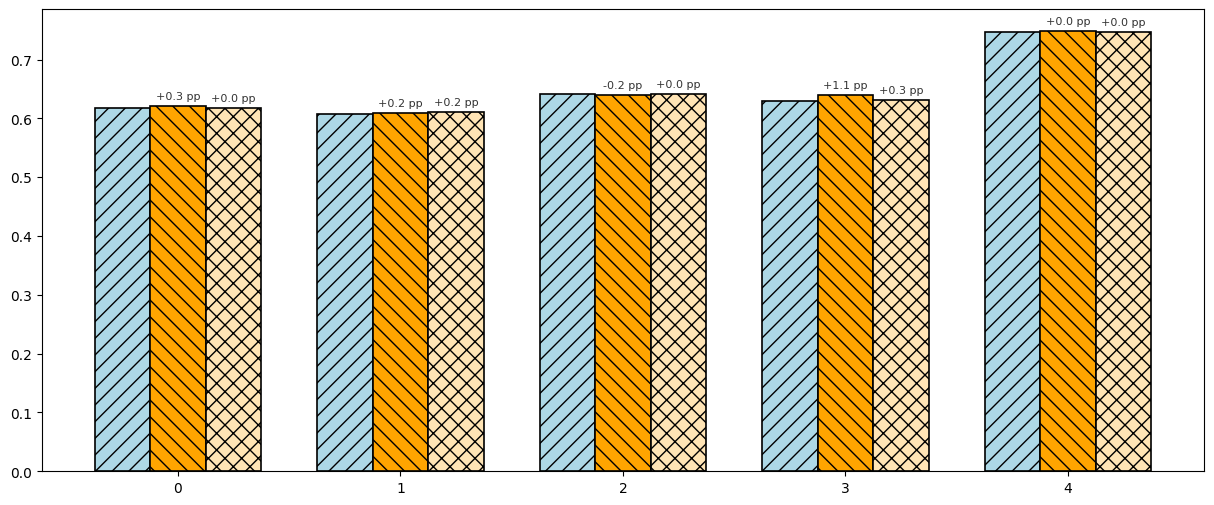

In [ ]:
common_keys    = [k for k in base_results if k in race_results and k in gender_results]
base_scores    = [get_score(base_results[k])   for k in common_keys]
race_scores    = [get_score(race_results[k])   for k in common_keys]
gender_scores  = [get_score(gender_results[k]) for k in common_keys]
deltas_race    = [(r - b) * 100 for b, r in zip(base_scores, race_scores)]
deltas_gender  = [(g - b) * 100 for b, g in zip(base_scores, gender_scores)]

fig, ax = plt.subplots(figsize=(max(9, len(common_keys) * 3.0), 6))

bar_width = 0.25
x = np.arange(len(common_keys))

ax.bar(
    x - bar_width, base_scores,
    width=bar_width,
    color="lightblue", edgecolor="black", linewidth=1.2, hatch="//",
    label="Baseline",
)
bars_race = ax.bar(
    x, race_scores,
    width=bar_width,
    color="orange", edgecolor="black", linewidth=1.2, hatch="\\\\",
    label="Race Intervention (EXPLICIT_SCALES)",
)
bars_gender = ax.bar(
    x + bar_width, gender_scores,
    width=bar_width,
    color="moccasin", edgecolor="black", linewidth=1.2, hatch="xx",
    label="Gender Intervention (EXPLICIT_SCALES_GENDER)",
)

for bar, delta in zip(bars_race, deltas_race):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.008,
        f"{delta:+.1f} pp",
        ha="center", va="bottom", fontsize=8, color="#333333",
    )
for bar, delta in zip(bars_gender, deltas_gender):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.008,
        f"{delta:+.1f} pp",
        ha="center", va="bottom", fontsize=8, color="#333333",
    )